# Cross-method noise floor analysis (Stream F)

Reads per-vertical noise-floor parquets produced by `analysis-noise-floors`:

- `{vertical}_nf.parquet` -- rolled-up MAR / IQR / n_obs per (descriptor, element-or-pair)
- `{vertical}_nf_charge_atoms.parquet` -- per-atom charges across 6 schemes
- `{vertical}_nf_exemplars.parquet` -- top-k disagreement cases

Plan: `docs/plans/2026-05-03-analysis-implementation-plan_F_noise_floors.md`

**Figures (final set):**
- F5a: Charge MAR heatmap (vertical x scheme-pair) -- B1 headline
- F5b: Bond-order MAR heatmap (vertical x scheme-pair) -- B2 headline
- F6a: Per-element charge MAR (element x scheme-pair) -- B1 detail
- F6b: ECP outlier diagnostic on TM atoms -- B1 caveat

**Parquet outputs (no figure, fed into LaTeX / case studies):**
- `T4_per_vertical_floor.parquet` -- T4 table source (one row per vertical)
- `top_exemplars.parquet` -- top-100 disagreements per descriptor for §6.5 case studies
- `bond_parser_artifacts.parquet` -- bond rows with residual >= 5 (parser-bug investigation)

**MAR definition.** For a scheme pair `(A, B)`, residual at each atom is `|q_A - q_B|`.
MAR is the median of those absolute residuals across all atoms in the vertical. Robust
measure of typical pairwise disagreement, in the same units as the descriptor (electrons
for charge, bond-order units for bonds). NOT a variance.

**Coverage.** When this notebook was first built, 17 / 34 verticals had completed
streaming. Re-running after the corpus finishes picks up the rest automatically.


In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "xtick.labelsize":   7,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "axes.grid":         True,
    "axes.grid.axis":    "y",
    "grid.linewidth":    0.5,
    "grid.alpha":        0.4,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "figure.dpi":        150,
})

DATA = Path("../../data/OMol4M_lmdbs/noise")
SAVE = Path("../../docs/neurips/figures/noise")
SAVE.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(SAVE / f"{name}.{ext}", dpi=300, bbox_inches="tight")
    print(f"saved {name}")


# Locked schemes (mayer_orca charge excluded - = Mulliken duplicate)
CHARGE_SCHEMES = ["hirshfeld", "cm5", "adch", "becke", "mulliken_orca", "loewdin_orca"]
BOND_SCHEMES = ["fuzzy_bond", "mayer_orca", "loewdin_orca"]

# ECP-treated heavy elements - ADCH/Becke real-space integration breaks here
ECP_ELEMENTS = {"Mo", "Ru", "Pt", "Pd", "Cu", "Fe", "Ni", "Co", "Mn", "Zn",
                "Ag", "Au", "W", "Re", "Os", "Ir", "Hf", "Ta", "Rh", "Cd",
                "Ca", "Ba", "Sr"}

SCHEME_COLORS = {
    "hirshfeld":     "#0072B2",
    "cm5":           "#56B4E9",
    "adch":          "#D55E00",
    "becke":         "#CC79A7",
    "mulliken_orca": "#E69F00",
    "loewdin_orca":  "#009E73",
}

nf_files = sorted(DATA.glob("*_nf.parquet"))
nf = pd.concat([pd.read_parquet(f) for f in nf_files], ignore_index=True)
VERTICALS = sorted(nf["vertical"].unique())
global_rows = nf[nf["element"].isna() & nf["element_pair"].isna()].copy()
pair_order = [f"{a}_vs_{b}" for a, b in combinations(CHARGE_SCHEMES, 2)]

print(f"verticals: {len(VERTICALS)}  ({', '.join(VERTICALS)})")
print(f"total nf rows: {len(nf):,}  |  global rows: {len(global_rows):,}")


verticals: 17  (5A_elytes, ani1xbb, ani2x, dna, droplet, electrolytes_reactivity, electrolytes_redox, electrolytes_scaled_sep, geom_orca6, low_spin_23, ml_elytes, ml_mo, ml_protein_interface, mo_hydrides, nakb, noble_gas, noble_gas_compounds)
total nf rows: 54,222  |  global rows: 408


## F5a. Charge MAR heatmap (vertical x scheme-pair) -- B1 headline

saved F5a_charge_mar_heatmap


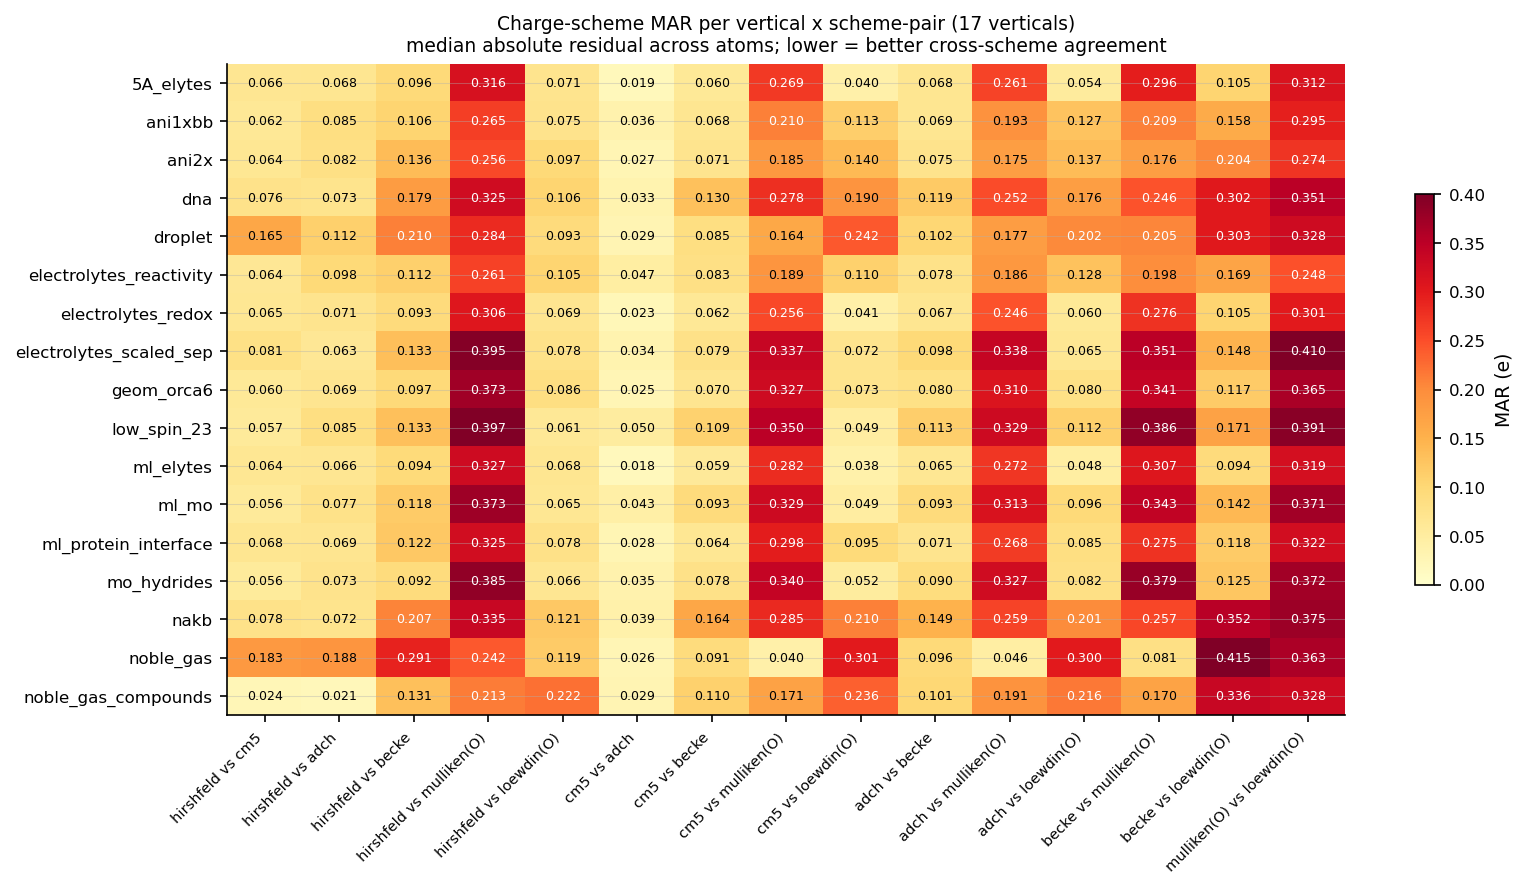


Global median charge MAR: 0.118 e
Worst scheme-pair across verticals (median): mulliken_orca_vs_loewdin_orca


In [2]:
charge_global = global_rows[global_rows["analysis"] == "charge"].copy()
pivot_a = charge_global.pivot(index="vertical", columns="descriptor", values="mar")
pivot_a = pivot_a.reindex(columns=[c for c in pair_order if c in pivot_a.columns])
pivot_a = pivot_a.reindex(index=sorted(pivot_a.index))

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_a.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.4)
ax.set_xticks(range(len(pivot_a.columns)))
ax.set_xticklabels([c.replace("_vs_", " vs ").replace("_orca", "(O)") for c in pivot_a.columns],
                   rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(pivot_a.index)))
ax.set_yticklabels(pivot_a.index, fontsize=8)
for ri in range(len(pivot_a.index)):
    for ci in range(len(pivot_a.columns)):
        val = pivot_a.iloc[ri, ci]
        if pd.notna(val):
            ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                    fontsize=6, color="white" if val > 0.2 else "black")
plt.colorbar(im, ax=ax, label="MAR (e)", shrink=0.6)
ax.set_title(f"Charge-scheme MAR per vertical x scheme-pair ({len(pivot_a.index)} verticals)\n"
             "median absolute residual across atoms; lower = better cross-scheme agreement")
plt.tight_layout()
save(fig, "F5a_charge_mar_heatmap")
plt.show()

print(f"\nGlobal median charge MAR: {charge_global['mar'].median():.3f} e")
worst = charge_global.groupby('descriptor')['mar'].median().idxmax()
print(f"Worst scheme-pair across verticals (median): {worst}")


## F5b. Bond-order MAR heatmap (vertical x scheme-pair) -- B2 headline

saved F5b_bond_mar_heatmap


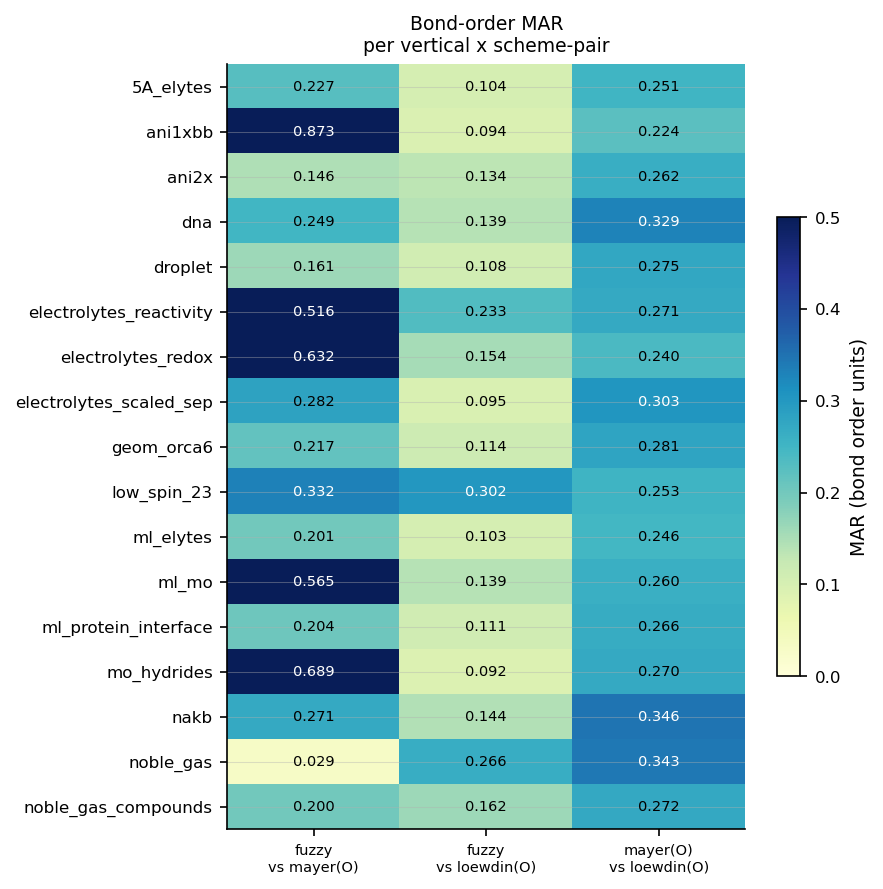


Global median bond-order MAR: 0.246


In [3]:
bond_global = global_rows[global_rows["analysis"] == "bond_order"].copy()
pivot_b = bond_global.pivot(index="vertical", columns="descriptor", values="mar")
bond_pair_order = [f"{a}_vs_{b}" for a, b in combinations(BOND_SCHEMES, 2)]
pivot_b = pivot_b.reindex(columns=[c for c in bond_pair_order if c in pivot_b.columns])
pivot_b = pivot_b.reindex(index=sorted(pivot_b.index))

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(pivot_b.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=0.5)
ax.set_xticks(range(len(pivot_b.columns)))
ax.set_xticklabels([c.replace("_vs_", "\nvs ").replace("_orca", "(O)").replace("_bond", "")
                    for c in pivot_b.columns], fontsize=7)
ax.set_yticks(range(len(pivot_b.index)))
ax.set_yticklabels(pivot_b.index, fontsize=8)
for ri in range(len(pivot_b.index)):
    for ci in range(len(pivot_b.columns)):
        val = pivot_b.iloc[ri, ci]
        if pd.notna(val):
            ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                    fontsize=7, color="white" if val > 0.3 else "black")
plt.colorbar(im, ax=ax, label="MAR (bond order units)", shrink=0.6)
ax.set_title("Bond-order MAR\nper vertical x scheme-pair")
plt.tight_layout()
save(fig, "F5b_bond_mar_heatmap")
plt.show()

print(f"\nGlobal median bond-order MAR: {bond_global['mar'].median():.3f}")


## F6a. Per-element charge MAR (element x scheme-pair) -- B1 detail

Charge-scheme MAR broken out by atomic element. For each (element, scheme-pair) we
sum `mar * n_obs` across verticals and divide by total `n_obs`, giving an n-weighted
combined MAR. Top 12 elements by total atom count are shown. Identifies elements
where method choice matters most (typical: heavy metals, ions).


saved F6a_charge_mar_per_element


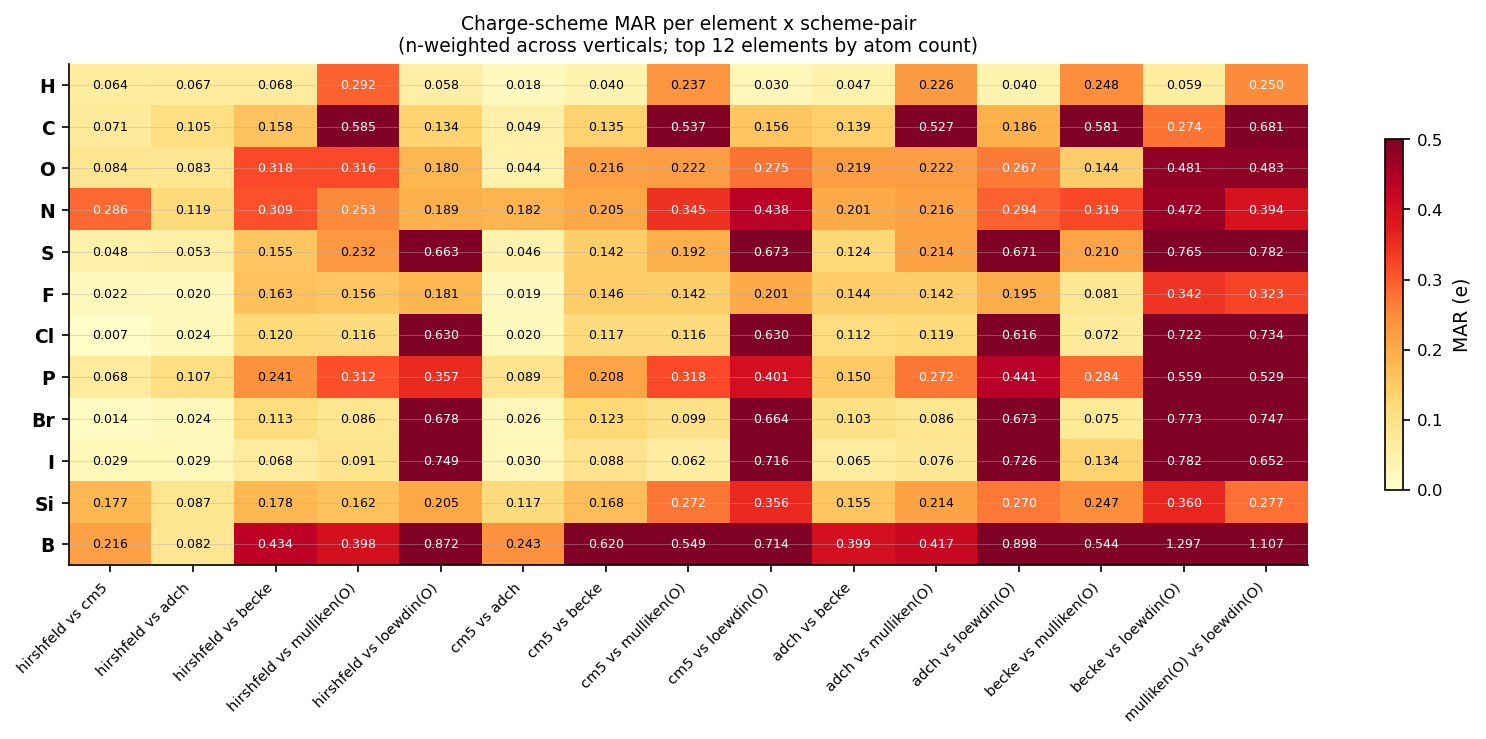

In [4]:
elem_rows = nf[(nf["analysis"] == "charge") & nf["element"].notna() & nf["element_pair"].isna()].copy()
combined_elem = (
    elem_rows.assign(mar_n=elem_rows["mar"] * elem_rows["n_obs"])
    .groupby(["element", "descriptor"])
    .agg(mar_n=("mar_n", "sum"), n=("n_obs", "sum"))
    .reset_index()
)
combined_elem["mar"] = combined_elem["mar_n"] / combined_elem["n"]

top_elems = (
    combined_elem.groupby("element")["n"].sum().sort_values(ascending=False).head(12).index.tolist()
)
pivot_c = combined_elem[combined_elem["element"].isin(top_elems)].pivot(
    index="element", columns="descriptor", values="mar"
).reindex(index=top_elems, columns=[c for c in pair_order if c in combined_elem["descriptor"].unique()])

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot_c.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.5)
ax.set_xticks(range(len(pivot_c.columns)))
ax.set_xticklabels([c.replace("_vs_", " vs ").replace("_orca", "(O)") for c in pivot_c.columns],
                   rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(pivot_c.index)))
ax.set_yticklabels(pivot_c.index, fontsize=9, fontweight="bold")
for ri in range(len(pivot_c.index)):
    for ci in range(len(pivot_c.columns)):
        val = pivot_c.iloc[ri, ci]
        if pd.notna(val):
            ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                    fontsize=6, color="white" if val > 0.25 else "black")
plt.colorbar(im, ax=ax, label="MAR (e)", shrink=0.7)
ax.set_title("Charge-scheme MAR per element x scheme-pair\n"
             "(n-weighted across verticals; top 12 elements by atom count)")
plt.tight_layout()
save(fig, "F6a_charge_mar_per_element")
plt.show()


## F6b. ECP outlier diagnostic -- B1 caveat

ECPs remove core electrons from heavy metals. ADCH and Becke do real-space basin
integration which assumes all electrons are present in the wavefunction; on
ECP-treated metals these schemes can produce charges of +/- 10 e or worse (observed
range -28 e to +18 e in 5A_elytes / mo_hydrides).

Each panel shows the charge distribution on ECP-treated elements (Mo, Ru, Cu, Fe,
Pt, ...) for one scheme. Dashed lines mark the +/- 5 e winsorize threshold the
paper recommends. Title reports the |q|>5e outlier fraction per scheme.


TM-bearing verticals available: ['mo_hydrides', '5A_elytes', 'ml_mo', 'low_spin_23']


ECP-element atom rows: 50,375


saved F6b_ecp_outlier_diagnostic


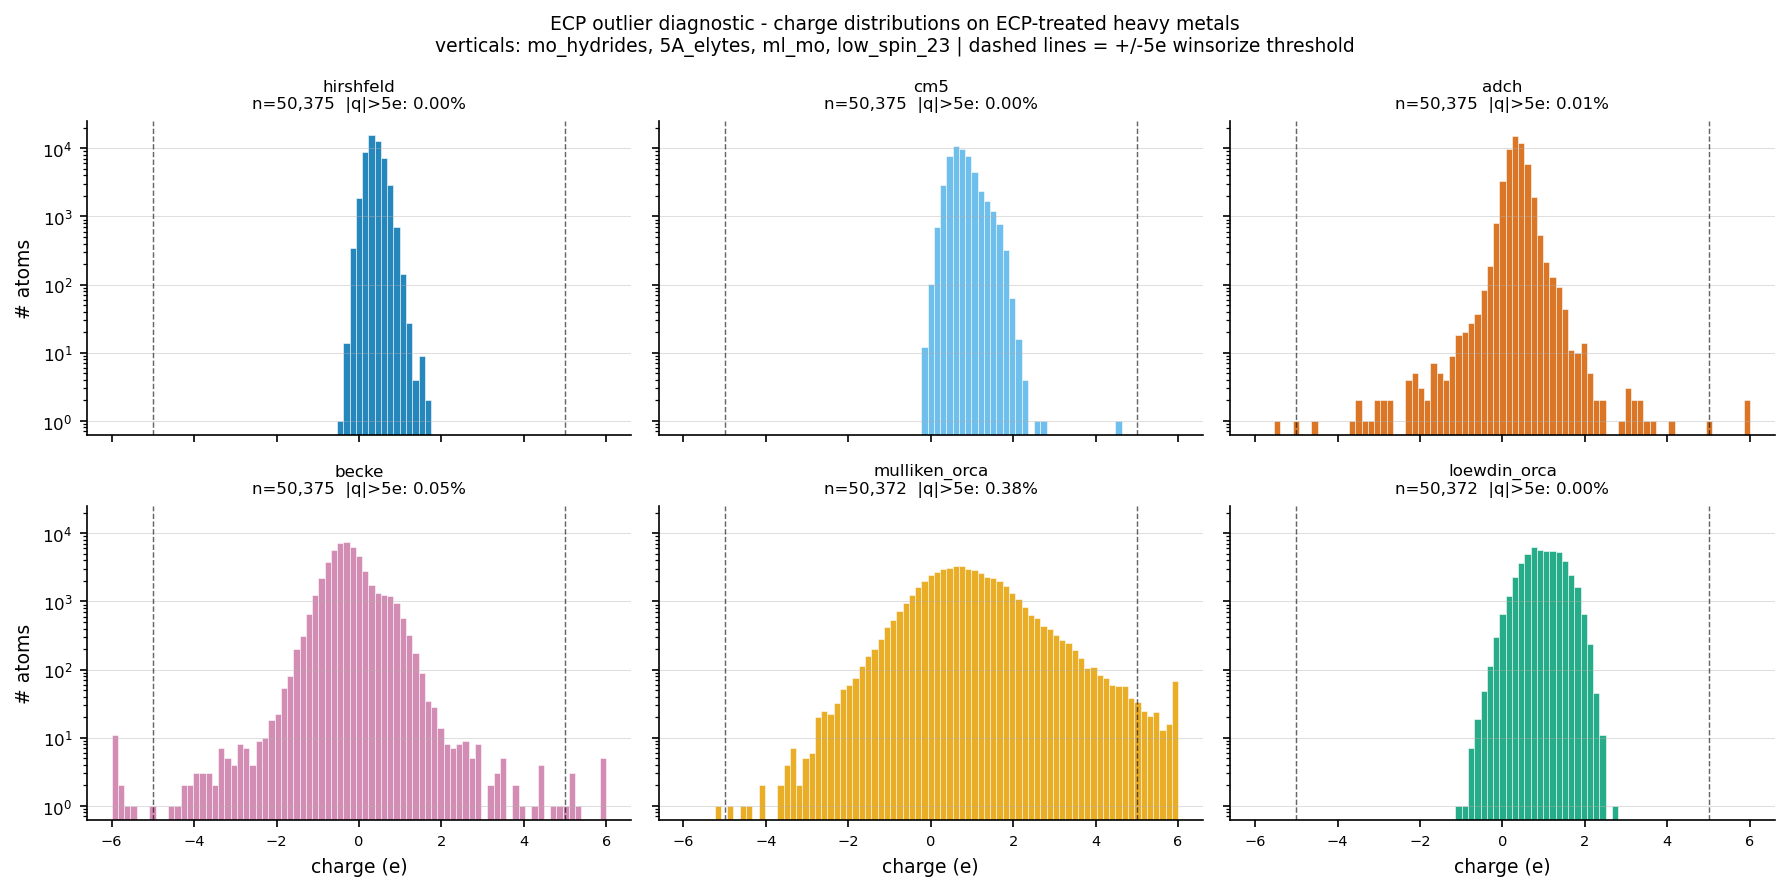

In [5]:
ecp_focus_verticals = [v for v in ["mo_hydrides", "5A_elytes", "ml_mo", "low_spin_23"] if v in VERTICALS]
print(f"TM-bearing verticals available: {ecp_focus_verticals}")

ecp_charge_dfs = []
for v in ecp_focus_verticals:
    p = DATA / f"{v}_nf_charge_atoms.parquet"
    if p.exists():
        df = pd.read_parquet(p)
        ecp_charge_dfs.append(df[df["element"].isin(ECP_ELEMENTS)])
ecp_df = pd.concat(ecp_charge_dfs, ignore_index=True) if ecp_charge_dfs else pd.DataFrame()
print(f"ECP-element atom rows: {len(ecp_df):,}")

if len(ecp_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
    bins = np.linspace(-6, 6, 80)
    for ax, scheme in zip(axes.flat, CHARGE_SCHEMES):
        col = f"charge_{scheme}"
        vals = ecp_df[col].dropna().values
        clipped = vals.clip(-6, 6)
        ax.hist(clipped, bins=bins, color=SCHEME_COLORS[scheme],
                alpha=0.85, edgecolor="white", linewidth=0.3)
        ax.axvline(-5, color="k", linestyle="--", linewidth=0.7, alpha=0.6)
        ax.axvline(5,  color="k", linestyle="--", linewidth=0.7, alpha=0.6)
        outlier_frac = float(((vals < -5) | (vals > 5)).mean()) if len(vals) else 0.0
        n_finite = int(np.isfinite(vals).sum())
        ax.set_title(f"{scheme}\nn={n_finite:,}  |q|>5e: {outlier_frac*100:.2f}%", fontsize=8)
        ax.set_yscale("log")
    for ax in axes[-1, :]:
        ax.set_xlabel("charge (e)")
    for ax in axes[:, 0]:
        ax.set_ylabel("# atoms")
    fig.suptitle(
        f"ECP outlier diagnostic - charge distributions on ECP-treated heavy metals\n"
        f"verticals: {', '.join(ecp_focus_verticals)} | dashed lines = +/-5e winsorize threshold",
        fontsize=9,
    )
    plt.tight_layout()
    save(fig, "F6b_ecp_outlier_diagnostic")
    plt.show()


## T4 source -- per-vertical floor (parquet only)

For each vertical, the median MAR across all charge scheme-pairs and bond-order
scheme-pairs. This is the "noise floor" reported in Table T4 of the paper -- a
lower bound on achievable ML error that future work using this benchmark should
report. Not plotted as a figure (redundant with the row-medians of F5a/F5b);
written as `T4_per_vertical_floor.parquet` for direct LaTeX `\input{}`.


In [6]:
floor_rows = []
for v in VERTICALS:
    sub = global_rows[global_rows["vertical"] == v]
    floor_rows.append({
        "vertical": v,
        "charge_floor_e": sub[sub["analysis"] == "charge"]["mar"].median(),
        "bond_floor": sub[sub["analysis"] == "bond_order"]["mar"].median(),
        "n_charge_obs": sub[sub["analysis"] == "charge"]["n_obs"].max(),
        "n_bond_obs":   sub[sub["analysis"] == "bond_order"]["n_obs"].max(),
    })
floor = pd.DataFrame(floor_rows).set_index("vertical").sort_values("charge_floor_e")
floor.to_parquet(SAVE / "T4_per_vertical_floor.parquet")
print(f"wrote {SAVE/'T4_per_vertical_floor.parquet'}")
print(floor.round(3).to_string())


wrote ../../docs/neurips/figures/noise/T4_per_vertical_floor.parquet
                         charge_floor_e  bond_floor  n_charge_obs  n_bond_obs
vertical                                                                     
ml_elytes                         0.068       0.201       7608642    13400770
electrolytes_redox                0.071       0.240       4017583     8778537
5A_elytes                         0.071       0.227       2324023     4190341
geom_orca6                        0.086       0.217      10321888    22826559
mo_hydrides                       0.090       0.270        232942      759393
ml_protein_interface              0.095       0.204       8314895    15474467
ml_mo                             0.096       0.260       6098677    17456047
electrolytes_scaled_sep           0.098       0.282       2307396     5367052
electrolytes_reactivity           0.112       0.271        874449     1886672
ani1xbb                           0.113       0.224      10834251    2684

## Top-exemplar source -- §6.5 case studies (parquet only)

Top-100 highest-spread atoms (charge) and bond pairs (bond_order) for case-study
selection in §6.5. Bond-order rows are filtered to physical range
(`residual < 5`); rows above that are stored separately as
`bond_parser_artifacts.parquet` for parser-quality investigation
(Multiwfn output failures on very large 5-shell solvent records).


In [7]:
ex_dfs = []
for v in VERTICALS:
    p = DATA / f"{v}_nf_exemplars.parquet"
    if p.exists():
        ex_dfs.append(pd.read_parquet(p))
ex_all = pd.concat(ex_dfs, ignore_index=True)
print(f"total exemplar rows: {len(ex_all):,}")

ex_charge       = ex_all[ex_all["descriptor"] == "charge"].copy()
ex_bond_clean   = ex_all[(ex_all["descriptor"] == "bond_order") & (ex_all["residual"] < 5)].copy()
ex_bond_corrupt = ex_all[(ex_all["descriptor"] == "bond_order") & (ex_all["residual"] >= 5)].copy()
print(f"  charge: {len(ex_charge):,}")
print(f"  bond clean: {len(ex_bond_clean):,}  |  bond parser-corrupt (residual>=5): {len(ex_bond_corrupt):,}")

top_charge = ex_charge.nlargest(100, "residual")
top_bond   = ex_bond_clean.nlargest(100, "residual")
top_exemplars = pd.concat([top_charge, top_bond], ignore_index=True)
top_exemplars.to_parquet(SAVE / "top_exemplars.parquet")
print(f"\nwrote {SAVE/'top_exemplars.parquet'}  ({len(top_exemplars)} rows)")

if len(ex_bond_corrupt):
    ex_bond_corrupt.to_parquet(SAVE / "bond_parser_artifacts.parquet")
    print(f"wrote {SAVE/'bond_parser_artifacts.parquet'}  ({len(ex_bond_corrupt)} rows)")

print("\n=== top-5 charge exemplars ===")
print(top_charge[["vertical", "element_or_pair", "residual", "key"]].head().to_string(index=False))
print("\n=== top-5 bond exemplars (filtered) ===")
print(top_bond[["vertical", "element_or_pair", "residual", "key"]].head().to_string(index=False))


total exemplar rows: 237,441
  charge: 25,751
  bond clean: 205,387  |  bond parser-corrupt (residual>=5): 6,303

wrote ../../docs/neurips/figures/noise/top_exemplars.parquet  (200 rows)
wrote ../../docs/neurips/figures/noise/bond_parser_artifacts.parquet  (6303 rows)

=== top-5 charge exemplars ===
               vertical element_or_pair  residual                                                           key
              ml_elytes               C 99.152819 elytes_md_eqv2_electro_3231_C4H6O2_3_group_8_shell_0_0_1_1198
              ml_elytes               O 39.650358 elytes_md_eqv2_electro_3231_C4H6O2_3_group_8_shell_0_0_1_1198
     electrolytes_redox               N 34.244238                                 3027_C8H18N+_3_shell_980_-1_2
electrolytes_reactivity               O 32.926380                                                   31237_1_0_1
     electrolytes_redox               O 32.530613                                  833_C4H11NO_3_shell_608_-1_2

=== top-5 bond exemplars (